# Example usage of `LogFalkonNPLM`

This notebook assumes your class is importable as:

```python
from nplm import LogFalkonNPLM
```

In [1]:
import numpy as np

from nplm import LogFalkonNPLM

from toy_data import (
    sample_ref_exp,
    make_data_sample_poisson,
    build_pooled_sample,
)

In [2]:
def sample_ref_exp(N, rate=8.0, xmax=1.0, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    Z = 1.0 - np.exp(-rate * xmax)
    u = rng.random(N)
    return -(1.0 / rate) * np.log(1.0 - u * Z)


def sample_signal_gauss(N, mu=0.8, sigma=0.02, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    return rng.normal(loc=mu, scale=sigma, size=N)


def make_data_sample_poisson(NR=2000, NS=10, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    N_B = int(rng.poisson(NR))
    N_S = int(rng.poisson(NS))

    xb = sample_ref_exp(N_B, rng=rng)
    xs = sample_signal_gauss(N_S, rng=rng)

    x = np.concatenate([xb, xs])
    rng.shuffle(x)
    return x, xb, xs, N_B, N_S


def build_pooled_sample(x_ref, x_dat):
    X = np.concatenate([x_ref, x_dat]).reshape(-1, 1).astype(np.float64)
    y = np.concatenate([
        np.zeros(len(x_ref)),
        np.ones(len(x_dat)),
    ]).astype(np.float64)
    return X, y

In [3]:
# Parameters
seed = 0
rng = np.random.default_rng(seed)

N_R = 200_000
NR = 2_000
sigma = 0.3

cfg = {
    "sigma": float(sigma),
    "NR": float(NR),
    "M": 3000,
    "lambda": [1e-10],
    "cpu": False,
    "verbose": 0,
    "keops": "yes" 
}

In [ ]:
# --------------------------------
# Single toy dataset
# --------------------------------

# --- split ref/data back out (1D here, but works the same for d-D) ---
data = x_dat.reshape(-1, 1)
ref  = x_ref.reshape(-1, 1)

# --- get model scores on REF only (logits) ---
# (details["scores"] are pooled; easiest is to predict on ref directly)
ref_scores = nplm.model.predict(
    torch.from_numpy(ref.astype(np.float64, copy=False))
).detach().cpu().numpy()   # shape (N_R, 1)

# --- make the marginal plots (here d=1 so it produces 1 figure) ---
df = None  # if you want the chi2->Z display; otherwise set df=None
plot_reconstruction_marginals(
    df=df,
    data=data,
    weight_data=1.0,            # your data histogram weights
    ref=ref,
    weight_ref=nplm.weight,     # IMPORTANT: NR/N_R (matches your loss weighting convention)
    t_obs=t_obs,
    ref_scores=ref_scores,
    feature_names=["x"],
    bins=24,
    x_ranges=[(0.0, 1.5)],      # match your old plot; omit to auto-range
    save=False,                 # or True
    save_path="plots/",
    file_prefix="nplm_reco",
    show=True,
)

In [11]:
# Null toys
NS = 0
B = 10
t_null = np.empty(B)

for b in range(B):
    print(f"--- Null toy {b + 1}/{B} ---")
    x_ref_b = sample_ref_exp(N_R, rng=rng)
    x_dat_b, _, _, _, _ = make_data_sample_poisson(NR=NR, NS=NS, rng=rng)

    X_b, y_b = build_pooled_sample(x_ref_b, x_dat_b)
    nplm = LogFalkonNPLM(cfg)
    t_null[b] = nplm.compute_statistic(X_b, y_b)

np.save("nplm_null_stats.npy", t_null)
print("Saved nplm_null_stats.npy")

--- Null toy 1/10 ---
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000


--- Null toy 2/10 ---
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Null toy 3/10 ---
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Null toy 4/10 ---
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Null toy 5/10 ---
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Null toy 6/10 ---
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Null toy 7/10 ---
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Null toy 8/10 ---
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Null toy 9/10 ---
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Null toy 10/10 ---
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
Saved nplm_null_stats.npy


In [12]:
# Alternative toys
NS = 10
B = 10
t_alt = np.empty(B)

for b in range(B):
    print(f"--- Alt toy {b + 1}/{B} ---")
    x_ref_b = sample_ref_exp(NR, rng=rng)
    x_dat_b, _, _, _, _ = make_data_sample_poisson(NR=NR, NS=NS, rng=rng)

    print(len(x_dat_b), "data points in alt toy")

    X_b, y_b = build_pooled_sample(x_ref_b, x_dat_b)
    nplm = LogFalkonNPLM(cfg)
    t_alt[b] = nplm.compute_statistic(X_b, y_b)

np.save("nplm_alt_stats.npy", t_alt)
print("Saved nplm_alt_stats.npy")

--- Alt toy 1/10 ---
1968 data points in alt toy
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Alt toy 2/10 ---
1991 data points in alt toy
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Alt toy 3/10 ---
2056 data points in alt toy
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Alt toy 4/10 ---
2031 data points in alt toy
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Alt toy 5/10 ---
1983 data points in alt toy
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Alt toy 6/10 ---
2091 data points in alt toy
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Alt toy 7/10 ---
2002 data points in alt toy
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Alt toy 8/10 ---
2077 data points in alt toy
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Alt toy 9/10 ---
1975 data points in alt toy
Iteration 0 - penalty 1.000000e-08 - sub-iterations 1000000
--- Alt toy 10/10 -

In [13]:
print(f"Null mean: {np.mean(t_null):.6g}")
print(f"Alt mean:  {np.mean(t_alt):.6g}")

Null mean: 4.87905
Alt mean:  31.5044


p-value = 0.09091
Emp. Z score = 1.28


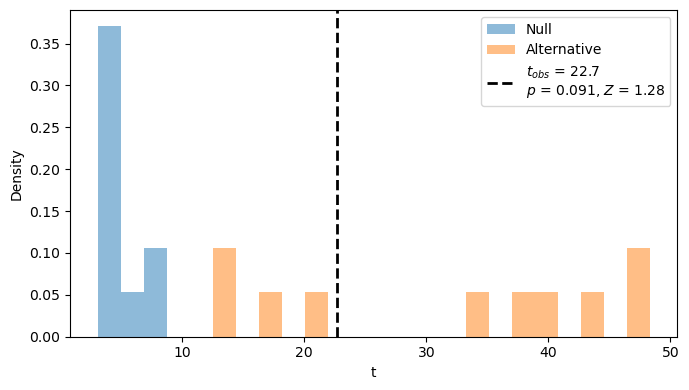

In [14]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# --------------------------------
# Empirical Z-score
# --------------------------------
def emp_zscore(t0, t1):
    if max(t0) <= t1:
        p_obs = 1 / len(t0)
    else:
        p_obs = np.count_nonzero(t0 >= t1) / len(t0)
    Z_obs = round(norm.ppf(1 - p_obs), 2)
    return Z_obs


# --------------------------------
# Monte Carlo p-value
# --------------------------------
B = len(t_null)
p_value = (1.0 + np.sum(t_null >= t_obs)) / (B + 1.0)
Z_obs = emp_zscore(t_null, t_obs)

print(f"p-value = {p_value:.4g}")
print(f"Emp. Z score = {Z_obs}")


# --------------------------------
# Common bins (important!)
# --------------------------------
bins = np.linspace(
    min(min(t_null), min(t_alt)),
    max(max(t_null), max(t_alt)),
    25
)

# --------------------------------
# Plot
# --------------------------------
plt.figure(figsize=(7, 4))

plt.hist(
    t_null,
    bins=bins,
    density=True,
    alpha=0.5,
    label="Null"
)

plt.hist(
    t_alt,
    bins=bins,
    density=True,
    alpha=0.5,
    label="Alternative"
)

plt.axvline(
    t_obs,
    color="black",
    linestyle="--",
    linewidth=2,
    label=fr"$t_{{obs}}$ = {t_obs:.3g}" + "\n"
          + fr"$p$ = {p_value:.2g}, $Z$ = {Z_obs}"
)

plt.xlabel("t")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()